# FlashAttention-2 — memory

The forward kernel streams over key/value tiles and keeps only per-row running
statistics, so its intermediate storage is O(N) rather than the O(N^2) attention
matrix the naive implementation has to allocate. This notebook measures that and
finds the sequence length where naive attention runs out of memory.

In [1]:
import gc

import matplotlib.pyplot as plt
import pandas as pd
import torch

from kernels.flash_attention.kernel import flash_attention_forward, naive_attention

print(f"GPU:   {torch.cuda.get_device_name(0)}")
total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM:  {total_gb:.1f} GB")

GPU:   NVIDIA GeForce RTX 4070 Ti
VRAM:  12.5 GB


## Measurement

`torch.cuda.max_memory_allocated` reports the peak of the caching allocator, so
the counter is reset and the cache emptied before each measurement — otherwise a
previous run's block reuse hides the true peak.

In [2]:
def peak_memory_gb(fn, *args, **kwargs):
    """Peak allocator high-water mark for one call, or None on OOM.

    Arguments are forwarded rather than captured in a closure: a lambda defined
    in a loop would bind the loop variable by reference, not by value.
    """
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    try:
        out = fn(*args, **kwargs)
        torch.cuda.synchronize()
        peak = torch.cuda.max_memory_allocated() / 1e9
        del out
        return peak
    except torch.OutOfMemoryError:
        return None
    finally:
        gc.collect()
        torch.cuda.empty_cache()


BATCH, HEADS, HEAD_DIM = 1, 8, 64
# 32768 is included because naive attention must actually fail somewhere
# for the crossover to be a measurement rather than an assertion.
SEQ_LENS = [512, 1024, 2048, 4096, 8192, 16384, 32768]
DTYPE = torch.float16

In [3]:
def _flash_out(q, k, v):
    return flash_attention_forward(q, k, v, is_causal=False)[0]


rows = []
for n in SEQ_LENS:
    q, k, v = (torch.randn(BATCH, HEADS, n, HEAD_DIM, device="cuda", dtype=DTYPE)
               for _ in range(3))
    inputs_gb = 3 * q.numel() * q.element_size() / 1e9
    naive = peak_memory_gb(naive_attention, q, k, v, is_causal=False)
    flash = peak_memory_gb(_flash_out, q, k, v)
    rows.append(dict(seq_len=n, inputs_gb=round(inputs_gb, 4),
                     naive_gb=round(naive, 4) if naive else None,
                     flash_gb=round(flash, 4) if flash else None,
                     ratio=round(naive / flash, 1) if naive and flash else None))
    del q, k, v
    gc.collect()
    torch.cuda.empty_cache()
    print(f"N={n:>6}  naive={'OOM' if naive is None else f'{naive:7.3f} GB'}"
          f"   flash={'OOM' if flash is None else f'{flash:7.3f} GB'}")

df = pd.DataFrame(rows)
df

N=   512  naive=  0.019 GB   flash=  0.011 GB


N=  1024  naive=  0.046 GB   flash=  0.013 GB


N=  2048  naive=  0.151 GB   flash=  0.017 GB


N=  4096  naive=  0.562 GB   flash=  0.025 GB


N=  8192  naive=  2.190 GB   flash=  0.042 GB


N= 16384  naive=  8.666 GB   flash=  0.076 GB


[W909 02:24:08.027258395 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 17179869184 bytes (free: 10740432896, total: 12450922496).
[W909 02:24:08.028256836 CUDACachingAllocator.cpp:3934] memory allocation failed with OOM on device 0 while trying to allocate 17179869184 bytes (free: 10740432896, total: 12450922496).


N= 32768  naive=OOM   flash=  0.144 GB


,seq_len,inputs_gb,naive_gb,flash_gb,ratio
0,512,0.0016,0.0190,0.0106,1.8
1,1024,0.0031,0.0463,0.0127,3.6
2,2048,0.0063,0.1511,0.0170,8.9
3,4096,0.0126,0.5622,0.0254,22.1
4,8192,0.0252,2.1896,0.0423,51.7
5,16384,0.0503,8.6656,0.0762,113.8
6,32768,0.1007,NaN,0.1438,NaN


## Peak memory vs sequence length

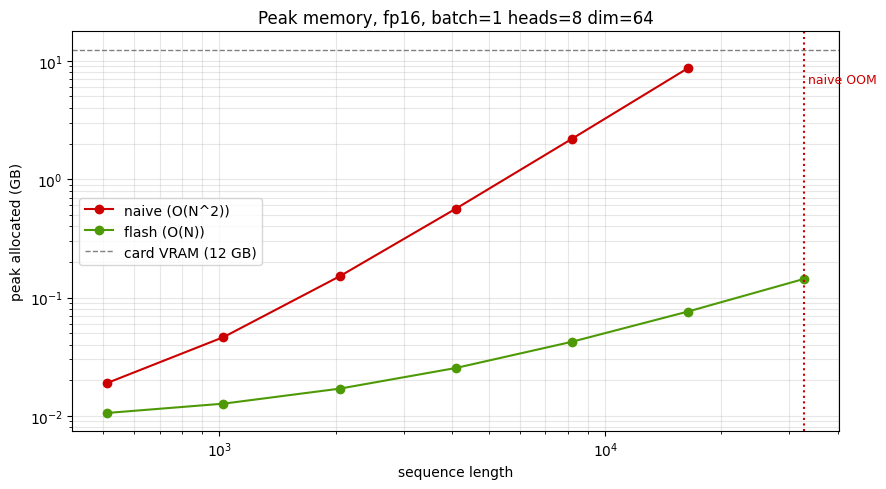

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ok_naive = df.dropna(subset=["naive_gb"])
ax.plot(ok_naive.seq_len, ok_naive.naive_gb, "o-", color="#cc0000", label="naive (O(N^2))")
ok_flash = df.dropna(subset=["flash_gb"])
ax.plot(ok_flash.seq_len, ok_flash.flash_gb, "o-", color="#4e9a06", label="flash (O(N))")
ax.axhline(total_gb, color="gray", ls="--", lw=1, label=f"card VRAM ({total_gb:.0f} GB)")

oom = df[df.naive_gb.isna()]
if len(oom):
    ax.axvline(oom.seq_len.iloc[0], color="#cc0000", ls=":", lw=1.5)
    ax.text(oom.seq_len.iloc[0], ax.get_ylim()[1] * 0.5, " naive OOM",
            color="#cc0000", fontsize=9)

ax.set(xlabel="sequence length", ylabel="peak allocated (GB)",
       xscale="log", yscale="log", title="Peak memory, fp16, batch=1 heads=8 dim=64")
ax.grid(alpha=.3, which="both")
ax.legend()
fig.tight_layout()

## Memory reduction factor

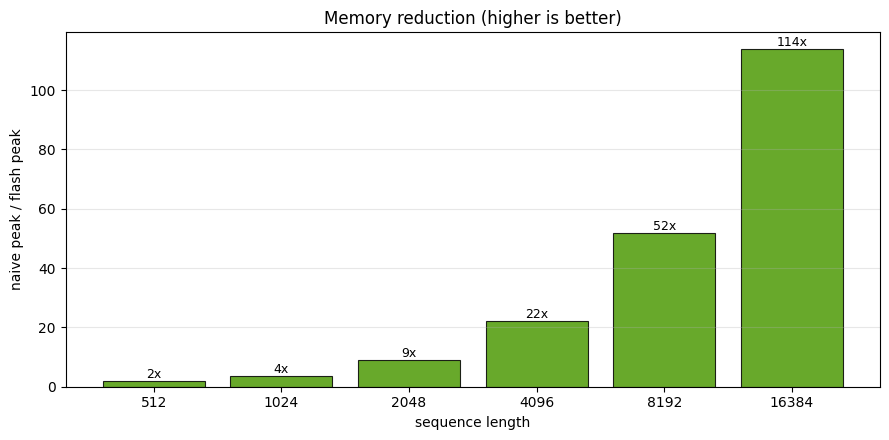

In [5]:
both = df.dropna(subset=["naive_gb", "flash_gb"])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([str(s) for s in both.seq_len], both.ratio, color="#4e9a06", alpha=.85,
       edgecolor="black", linewidth=.8)
for x, r in zip(range(len(both)), both.ratio, strict=True):
    ax.text(x, r, f"{r:.0f}x", ha="center", va="bottom", fontsize=9)
ax.set(xlabel="sequence length", ylabel="naive peak / flash peak",
       title="Memory reduction (higher is better)")
ax.grid(alpha=.3, axis="y")
fig.tight_layout()

## Reading the numbers

The reduction factor grows with N because naive attention's peak is dominated by
the N x N score matrix while the streaming kernel's is dominated by Q, K, V
themselves, which are linear in N. Note that the *backward* pass in this
implementation is not tiled — it recomputes the full matrix, so it is O(N^2)
regardless of what the forward does. That limit is documented in the slice README.